## Module 2: Fitting the Linear Model

### Step 0

Load the appropriate libraries and bring in the data. Note that we have to run a script to get the [California Housing dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html) to match as it is in scikit-learn. We cannot pull it directly from scikit-learn since CodeGrade cannot access the internet.

In [1]:
# CodeGrade step0

from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
import os
import tarfile
import joblib # Import joblib directly
from sklearn.datasets._base import _pkl_filepath, get_data_home
import statsmodels.api as sm


archive_path = "cal_housing.tgz" # change the path if it's not in the current directory
data_home = get_data_home(data_home=None) # change data_home if you are not using ~/scikit_learn_data
if not os.path.exists(data_home):
    os.makedirs(data_home)
filepath = _pkl_filepath(data_home, 'cal_housing.pkz')

with tarfile.open(mode="r:gz", name=archive_path) as f:
    cal_housing = np.loadtxt(
        f.extractfile('CaliforniaHousing/cal_housing.data'),
        delimiter=',')
    # Columns are not in the same order compared to the previous
    # URL resource on lib.stat.cmu.edu
    columns_index = [8, 7, 2, 3, 4, 5, 6, 1, 0]
    cal_housing = cal_housing[:, columns_index]

    joblib.dump(cal_housing, filepath, compress=6) # Now using the directly imported joblib

# Load the dataset
california = fetch_california_housing(as_frame=True)
data = california.data
target = california.target

In [4]:
data

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


### Step 1

*   Create a copy of the data and call it `df`
*   Select the `X` variable to be `MedInc` and the `y` be `MedianHouseValue`

Return `X.shape, y.shape` to verify.

In [5]:
# CodeGrade step1
df = data.copy()
X = df[['MedInc']]
y = target
X.shape, y.shape


((20640, 1), (20640,))

### Step 2

Using `statsmodels`


*   Add the constant term and call it `X_const`
*   fit the OLS model and call it `model`
*   extract the residuals and call them `residuals`
*   count the number of positive and negative residuals, calling them `positive_residuals` and `negative_residuals`, respectively

Return `positive_residuals, negative_residuals` to verify.

In [12]:
# CodeGrade step2
X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()
residuals = model.resid
positive_residuals = np.sum(residuals > 0)
negative_residuals = np.sum(residuals < 0)
positive_residuals, negative_residuals

(np.int64(8375), np.int64(12265))

In [15]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            MedHouseVal   R-squared:                       0.473
Model:                            OLS   Adj. R-squared:                  0.473
Method:                 Least Squares   F-statistic:                 1.856e+04
Date:                Sat, 12 Sep 2026   Prob (F-statistic):               0.00
Time:                        12:13:35   Log-Likelihood:                -25623.
No. Observations:               20640   AIC:                         5.125e+04
Df Residuals:                   20638   BIC:                         5.127e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4509      0.013     34.082      0.000       0.425       0.477
MedInc         0.4179      0.003    136.223      0.000       0.412       0.424
==============================================================================
Omnibus:                     4245.795   Durbin-Watson:                   0.655
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             9273.446
Skew:                           1.191   Prob(JB):                         0.00
Kurtosis:                       5.260   Cond. No.                         10.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Code

Compute and return $r^2$, calling it `r_squared`.

In [14]:
# CodeGrade step3
r_squared = model.rsquared
r_squared


np.float64(0.47344749180719903)

Plot the residual plot.

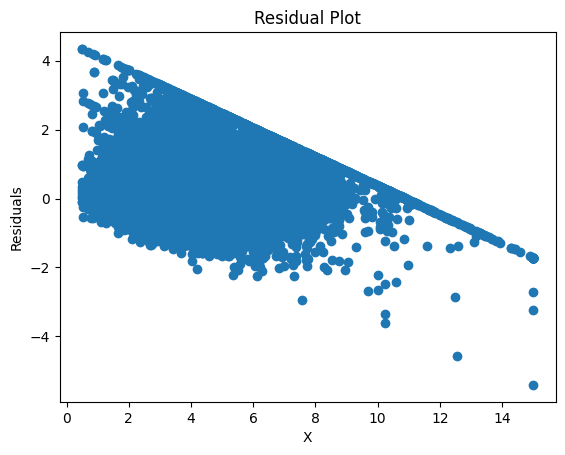

In [16]:
# Residual plot
plt.scatter(X, residuals)
plt.xlabel('X')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

### Step 4

Compute Cook's distance, where the model's `get_influence` is called `influence` and the Cook's distance from this is called `cooks_d`.

Then identify the influential points, calling them `influential_points`. Verify this by returing `influential_points.shape`.

In [21]:
# CodeGrade step4
influence = model.get_influence()
cooks_d = influence.cooks_distance[0]
influential_points = np.where(cooks_d > 4/len(X))[0]
influential_points.shape


(1230,)

Now plot Cook's Distance.

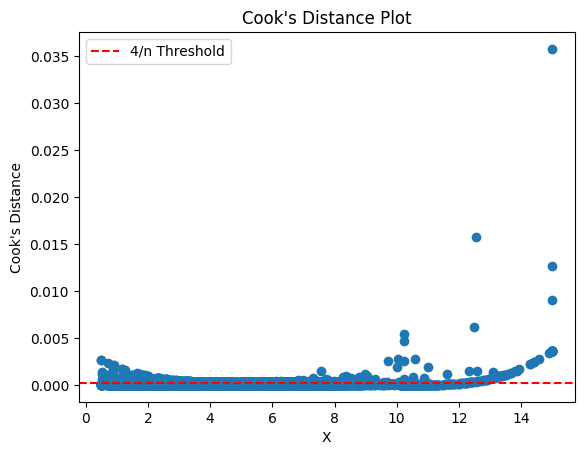

In [22]:
# Plot Cook's Distance
plt.scatter(X, cooks_d)

# Add the 4/n threshold line
plt.axhline(y=4/len(X), color='r', linestyle='--', label='4/n Threshold')

plt.xlabel('X')
plt.ylabel('Cook\'s Distance')
plt.title('Cook\'s Distance Plot')
plt.legend() # Displays the label for the red line
plt.show()

